# Foreign EDA

 exploratory data analysis for the foreign-currency pipeline.

Main questions:

1. What tables are used in the foreign pipeline?
2. How do the normal and abnormal pools differ?
3. Are the feature tables and master tables joinable?
4. What does the EDA suggest about later feature use?


# 1. Setup

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent
DATA_ROOT = ROOT / "data"
RAW_ROOT = DATA_ROOT / "normal"
SAR_ROOT = DATA_ROOT / "abnormal"
FEATURE_ROOT = DATA_ROOT / "特徵資料"

ROOT

PosixPath('/Users/ren/Desktop/karen/git_karen/Financial-Transaction-Anomaly-Detection')

## 2. Load Foreign Tables

This notebook focuses on the foreign-currency source tables before feature engineering.

- `FSTXN`: foreign transaction records
- `FSCST`: foreign account records
- `CFACCOUNT`: account master table
- `CFMASTER`: customer master table

For readability, this notebook interprets the two source pools as:

- `normal`: baseline pool
- `abnormal`: SAR-oriented pool


In [5]:
fstxn_normal = pd.read_csv(RAW_ROOT / "FSTXN.csv", low_memory=False)
fstxn_abnormal = pd.read_csv(SAR_ROOT / "FSTXN_SAR.csv", low_memory=False)

fscst_normal = pd.read_csv(RAW_ROOT / "FSCST.csv", low_memory=False)
fscst_abnormal = pd.read_csv(SAR_ROOT / "FSCST_SAR.csv", low_memory=False)

cfaccount_normal = pd.read_csv(RAW_ROOT / "CFACCOUNT.csv", low_memory=False)
cfaccount_abnormal = pd.read_csv(SAR_ROOT / "CFACCOUNT_SAR.csv", low_memory=False)

cfmaster_normal = pd.read_csv(RAW_ROOT / "CFMASTER.csv", low_memory=False)
cfmaster_abnormal = pd.read_csv(SAR_ROOT / "CFMASTER_SAR.csv", low_memory=False)

In [6]:
tables = {
    "fstxn_normal": fstxn_normal,
    "fstxn_abnormal": fstxn_abnormal,
    "fscst_normal": fscst_normal,
    "fscst_abnormal": fscst_abnormal,
    "cfaccount_normal": cfaccount_normal,
    "cfaccount_abnormal": cfaccount_abnormal,
    "cfmaster_normal": cfmaster_normal,
    "cfmaster_abnormal": cfmaster_abnormal,
}


def table_summary(name: str, df: pd.DataFrame) -> dict:
    return {
        "table": name,
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "duplicate_rows": int(df.duplicated().sum()),
    }


pd.DataFrame([table_summary(name, df) for name, df in tables.items()])

,table,rows,columns,duplicate_rows
0,fstxn_normal,2452,27,0
1,fstxn_abnormal,7,27,0
2,fscst_normal,3627,85,0
3,fscst_abnormal,21,85,1
4,cfaccount_normal,16363,9,0
5,cfaccount_abnormal,113,9,5
6,cfmaster_normal,16385,16,6385
7,cfmaster_abnormal,113,16,65


## 3. Data Quality Checks

Missingness and duplicated rows should be checked before feature engineering, because both can distort later aggregations and joins.

In [7]:
def missing_summary(name: str, df: pd.DataFrame) -> dict:
    missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False)
    top_missing = missing_ratio[missing_ratio > 0].head(5)
    return {
        "table": name,
        "rows": int(df.shape[0]),
        "duplicate_rows": int(df.duplicated().sum()),
        "columns_with_missing": int((df.isna().sum() > 0).sum()),
        "top_missing_columns": list(top_missing.index),
        "top_missing_pct": [round(v, 2) for v in top_missing.tolist()],
    }


pd.DataFrame([missing_summary(name, df) for name, df in tables.items()])

,table,rows,duplicate_rows,columns_with_missing,top_missing_columns,top_missing_pct
0,fstxn_normal,2452,0,0,[],[]
1,fstxn_abnormal,7,0,0,[],[]
2,fscst_normal,3627,0,2,"[FSCST_CLS_DATE, FSCST_TRANS_DATE]","[99.89, 97.3]"
3,fscst_abnormal,21,1,2,"[FSCST_TRANS_DATE, FSCST_CLS_DATE]","[100.0, 100.0]"
4,cfaccount_normal,16363,0,2,"[CFACC_CLS_DATE, CFACC_OPEN_DATE]","[99.96, 0.02]"
5,cfaccount_abnormal,113,5,1,[CFACC_CLS_DATE],[99.12]
6,cfmaster_normal,16385,6385,2,"[AGE, CFMST_CHG_DATE]","[0.56, 0.38]"
7,cfmaster_abnormal,113,65,0,[],[]


## 4. Join Reliability Checks

The foreign pipeline depends on linking the foreign source tables back to `CFACCOUNT` and `CFMASTER`.

This check asks whether the account and customer keys can be aligned with reasonable confidence.

In [8]:
def normalize_key(series: pd.Series) -> pd.Series:
    return series.astype(str).str.replace(",", "", regex=False)


for df in [fstxn_normal, fstxn_abnormal, fscst_normal, fscst_abnormal, cfaccount_normal, cfaccount_abnormal]:
    if "ACC_RANDOM" in df.columns:
        df["ACC_RANDOM"] = normalize_key(df["ACC_RANDOM"])
    if "ID_RANDOM" in df.columns:
        df["ID_RANDOM"] = normalize_key(df["ID_RANDOM"])

for df in [cfmaster_normal, cfmaster_abnormal]:
    if "ID_RANDOM" in df.columns:
        df["ID_RANDOM"] = normalize_key(df["ID_RANDOM"])


pd.DataFrame(
    {
        "table": list(tables.keys()),
        "has_ID_RANDOM": ["ID_RANDOM" in df.columns for df in tables.values()],
        "has_ACC_RANDOM": ["ACC_RANDOM" in df.columns for df in tables.values()],
        "unique_ID_RANDOM": [df["ID_RANDOM"].nunique() if "ID_RANDOM" in df.columns else None for df in tables.values()],
        "unique_ACC_RANDOM": [df["ACC_RANDOM"].nunique() if "ACC_RANDOM" in df.columns else None for df in tables.values()],
    }
)

,table,has_ID_RANDOM,has_ACC_RANDOM,unique_ID_RANDOM,unique_ACC_RANDOM
0,fstxn_normal,True,True,788,818.0
1,fstxn_abnormal,True,True,4,4.0
2,fscst_normal,True,True,3331,3627.0
3,fscst_abnormal,True,True,20,20.0
4,cfaccount_normal,True,True,9999,16363.0
5,cfaccount_abnormal,True,True,48,108.0
6,cfmaster_normal,True,False,10000,NaN
7,cfmaster_abnormal,True,False,48,NaN


In [9]:
pd.DataFrame(
    {
        "check": [
            "fstxn normal keys found in fscst normal",
            "fstxn abnormal keys found in fscst abnormal",
            "fscst normal keys found in CFACCOUNT normal",
            "fscst abnormal keys found in CFACCOUNT abnormal",
        ],
        "match_rate": [
            round(fstxn_normal["ACC_RANDOM"].isin(set(fscst_normal["ACC_RANDOM"])).mean(), 4),
            round(fstxn_abnormal["ACC_RANDOM"].isin(set(fscst_abnormal["ACC_RANDOM"])).mean(), 4),
            round(fscst_normal["ACC_RANDOM"].isin(set(cfaccount_normal["ACC_RANDOM"])).mean(), 4),
            round(fscst_abnormal["ACC_RANDOM"].isin(set(cfaccount_abnormal["ACC_RANDOM"])).mean(), 4),
        ],
    }
)

,check,match_rate
0,fstxn normal keys found in fscst normal,1.0
1,fstxn abnormal keys found in fscst abnormal,1.0
2,fscst normal keys found in CFACCOUNT normal,1.0
3,fscst abnormal keys found in CFACCOUNT abnormal,1.0


## 5. Overlap Between Normal and Abnormal Pools

The foreign pipeline also needs to check whether the same accounts appear in both source pools.

In [10]:
normal_acc = set(fstxn_normal["ACC_RANDOM"])
abnormal_acc = set(fstxn_abnormal["ACC_RANDOM"])

pd.DataFrame(
    {
        "entity": ["ACC_RANDOM"],
        "normal_only": [len(normal_acc - abnormal_acc)],
        "abnormal_only": [len(abnormal_acc - normal_acc)],
        "overlap": [len(normal_acc & abnormal_acc)],
    }
)

,entity,normal_only,abnormal_only,overlap
0,ACC_RANDOM,817,3,1


## 6. Raw Table Shape and Sparsity

Before feature engineering, it is still useful to inspect the shape and sparsity of the foreign raw tables.

In [11]:
foreign_tables = {
    "fstxn_normal": fstxn_normal,
    "fstxn_abnormal": fstxn_abnormal,
    "fscst_normal": fscst_normal,
    "fscst_abnormal": fscst_abnormal,
}


def raw_shape_summary(name: str, df: pd.DataFrame) -> dict:
    missing_pct = (df.isna().mean() * 100)
    sparse_cols = int((missing_pct > 50).sum())
    return {
        "table": name,
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "sparse_columns_gt_50pct_missing": sparse_cols,
    }


pd.DataFrame([raw_shape_summary(name, df) for name, df in foreign_tables.items()])

,table,rows,columns,sparse_columns_gt_50pct_missing
0,fstxn_normal,2452,27,0
1,fstxn_abnormal,7,27,0
2,fscst_normal,3627,85,2
3,fscst_abnormal,21,85,2


## 7. Distribution Checks for Foreign Raw Tables

A simple distribution comparison helps show whether the normal and abnormal pools have different activity or information density before feature construction.

In [12]:
fstxn_activity = pd.DataFrame(
    {
        "group": ["normal"] * len(fstxn_normal) + ["abnormal"] * len(fstxn_abnormal),
        "non_null_count": fstxn_normal.notna().sum(axis=1).tolist() + fstxn_abnormal.notna().sum(axis=1).tolist(),
    }
)

fstxn_activity.head()

,group,non_null_count
0,normal,27
1,normal,27
2,normal,27
3,normal,27
4,normal,27


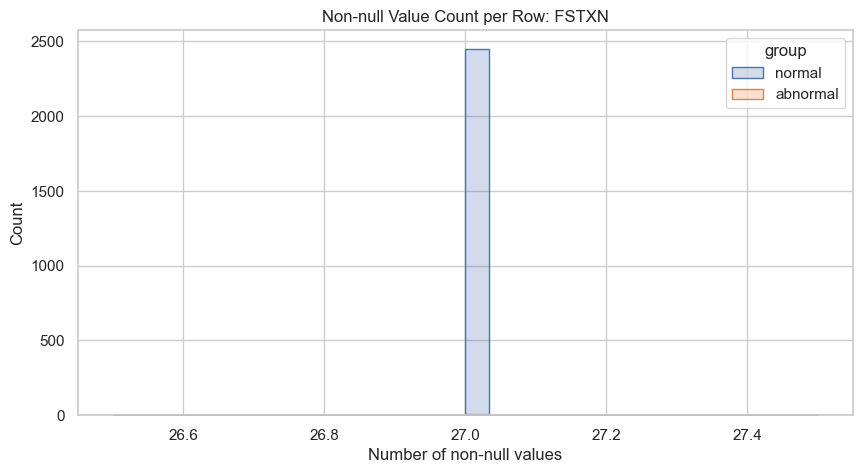

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(data=fstxn_activity, x="non_null_count", hue="group", bins=30, element="step", stat="count", common_norm=False)
plt.title("Non-null Value Count per Row: FSTXN")
plt.xlabel("Number of non-null values")
plt.ylabel("Count")
plt.show()

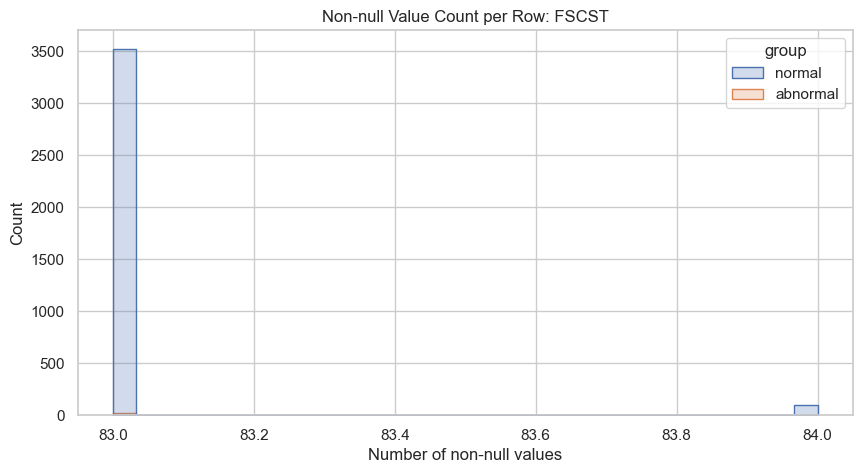

In [14]:
fscst_activity = pd.DataFrame(
    {
        "group": ["normal"] * len(fscst_normal) + ["abnormal"] * len(fscst_abnormal),
        "non_null_count": fscst_normal.notna().sum(axis=1).tolist() + fscst_abnormal.notna().sum(axis=1).tolist(),
    }
)

plt.figure(figsize=(10, 5))
sns.histplot(data=fscst_activity, x="non_null_count", hue="group", bins=30, element="step", stat="count", common_norm=False)
plt.title("Non-null Value Count per Row: FSCST")
plt.xlabel("Number of non-null values")
plt.ylabel("Count")
plt.show()